# 08 — Bipartite Optimality Analysis

This notebook studies the special case of bipartite Max-Cut instances with
only non-negative edge weights.

For such graphs, the optimal Max-Cut value is known exactly: assigning the two
bipartition sets to opposite sides of the cut separates every edge. Therefore,
the true optimum is equal to the sum of all edge weights.

The analysis focuses on the following questions:

1. How many benchmark instances satisfy the bipartite and non-negative
   edge-weight conditions, and how are these instances distributed across
   size and density categories?

2. How often do DAv3c, DAv2, DAv3, and the selected MQLib heuristics reach
   the exact optimal Max-Cut value on these instances?

The notebook also examines:

- Solver result availability across the filtered instance set
- The distribution of instances by `size_cat` and `density_cat`
- The MQLib heuristic responsible for each heuristic result
- Exact optimality gaps relative to the known optimum
- Optimality-hit percentages across all evaluated solvers

This analysis provides a correctness-oriented evaluation setting in which the
true optimum is analytically known, allowing solver performance to be assessed
without requiring external reference solutions.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd

#project imports
sys.path.append(str(Path("../src/maxcut").resolve()))

%load_ext autoreload
%autoreload 2

import config as cfg
import utils
import plotting

In [2]:
# import paths
PATH_BASELINE_DATASET = cfg.PROCESSED_DIR / 'baseline_dataset.csv'

In [3]:
df_baseline = pd.read_csv(PATH_BASELINE_DATASET)
df_baseline.head()

,name,nodes,edges,density,limit,has_leafs,int_only,size_cat,density_cat,heuristics_name,...,neg_edges_frac,neg_wt_sum,neg_wt_ratio,has_triangles,triangle_count,cyclomatic_number,transitivity,average_clustering,bridge_count,bridge_fraction
0,G55,4969,12498,0.001013,13.945,True,True,large,sparse,BURER2002,...,0.000000,0.0,0.000000,True,23,7530,0.001100,0.001189,180,0.014402
1,G56,4969,12498,0.001013,13.922,True,True,large,sparse,BURER2002,...,0.502160,-6276.0,0.502160,True,23,7530,0.001100,0.001189,180,0.014402
2,G57,5000,10000,0.000800,11.299,False,True,large,sparse,BURER2002,...,0.501900,-5019.0,0.501900,False,0,5001,0.000000,0.000000,0,0.000000
3,G58,5000,29570,0.002366,11.876,False,True,large,sparse,BURER2002,...,0.000000,0.0,0.000000,True,30784,24571,0.098091,0.326822,0,0.000000
4,G59,5000,29570,0.002366,15.875,False,True,large,sparse,BURER2002,...,0.498377,-14737.0,0.498377,True,30784,24571,0.098091,0.326822,0,0.000000


In [4]:
df_baseline = df_baseline[df_baseline['limit']>0.25]

In [5]:
df_final = df_baseline[(df_baseline['bipartite']==True) & (df_baseline['neg_edges']==0)]

In [6]:
(
    df_final["size_cat"]
    .value_counts()
    .reindex(cfg.SIZE_ORDER)
)

size_cat
xsmall    40
small     30
medium    42
large     24
xlarge    10
Name: count, dtype: int64

In [7]:
(
    df_final["density_cat"]
    .value_counts()
    .reindex(cfg.DENSITY_ORDER)
)

density_cat
sparse      146.0
balanced      NaN
dense         NaN
Name: count, dtype: float64

In [8]:
df_final[["DAv3c", "DAv3", "DAv2", "heuristic"]].notna().sum()

DAv3c        146
DAv3         146
DAv2         136
heuristic    146
dtype: int64

In [9]:
df_final['heuristics_name'].value_counts()

heuristics_name
BURER2002      136
MERZ1999GLS     10
Name: count, dtype: int64

In [10]:
heuristic_counts = df_final.groupby(['size_cat', 'heuristics_name']).size()
print(heuristic_counts)

size_cat  heuristics_name
large     BURER2002          24
medium    BURER2002          42
small     BURER2002          30
xlarge    MERZ1999GLS        10
xsmall    BURER2002          40
dtype: int64


In [11]:
df_final['int_only'].value_counts()

int_only
True     130
False     16
Name: count, dtype: int64

In [12]:
total = len(df_final)
obj_value = []

for i, graph_name in enumerate(df_final['name'], 1):
    progress = (i / total) * 100
    sys.stdout.write(
        f"\rProcessed {i}/{total} "
        f"({progress:.2f}%) | Current: {graph_name}"
    )
    sys.stdout.flush()

    zip_path = utils.find_zip_for_graph(graph_name)
    if zip_path is None:
        print(f'Missing ZIP for {graph_name}')
        continue

    try:
        _, edges, *_ = utils.read_edgelist_from_zip(zip_path) 
    except Exception:
        continue

    obj_value.append(sum(e[2] for e in edges))
    

Processed 146/146 (100.00%) | Current: g003251

In [13]:
len(obj_value)

146

In [14]:
df_final['Objective Value'] = obj_value

In [15]:
df_final.columns

Index(['name', 'nodes', 'edges', 'density', 'limit', 'has_leafs', 'int_only',
       'size_cat', 'density_cat', 'heuristics_name', 'DAv2', 'DAv2_runtime',
       'DAv3', 'DAv3_runtime', 'DAv3c', 'DAv3c_runtime', 'heuristic',
       'heuristic_runtime', 'baseline_objective', 'best_solvers', 'bipartite',
       'neg_edges', 'neg_edges_frac', 'neg_wt_sum', 'neg_wt_ratio',
       'has_triangles', 'triangle_count', 'cyclomatic_number', 'transitivity',
       'average_clustering', 'bridge_count', 'bridge_fraction',
       'Objective Value'],
      dtype='str')

In [17]:
common_df = df_final.dropna(
    subset=cfg.SOLVERS
)

opt_col = "Objective Value"

rows = []

for solver in cfg.SOLVERS:

    # keep only rows where both optimum and solver value exist
    valid = common_df[[opt_col, solver]].dropna()

    hit_optimum = np.isclose(
        valid[solver].astype(float),
        valid[opt_col].astype(float),
        rtol=0,
        atol=1e-9
    )

    rows.append({
        "solver": solver,
        "n_available": len(valid),
        "n_optimal": hit_optimum.sum(),
        "%Optimal": hit_optimum.mean() * 100
    })

opt_df = pd.DataFrame(rows)

opt_df

,solver,n_available,n_optimal,%Optimal
0,DAv2,136,125,91.911765
1,DAv3,136,131,96.323529
2,DAv3c,136,100,73.529412
3,heuristic,136,101,74.264706


In [18]:
for solver in cfg.SOLVERS:

    valid = df_final[[solver, "Objective Value", "size_cat"]].dropna()

    failed = valid[
        ~np.isclose(
            valid[solver],
            valid["Objective Value"],
            atol=1e-9
        )
    ]

    print(f"\n===== {solver} failures by size =====")

    print(
        failed["size_cat"]
        .value_counts()
        .reindex(cfg.SIZE_ORDER)
    )


===== DAv2 failures by size =====
size_cat
xsmall    NaN
small     1.0
medium    6.0
large     4.0
xlarge    NaN
Name: count, dtype: float64

===== DAv3 failures by size =====
size_cat
xsmall     1
small      1
medium     2
large      1
xlarge    10
Name: count, dtype: int64

===== DAv3c failures by size =====
size_cat
xsmall     1
small      4
medium    15
large     15
xlarge     6
Name: count, dtype: int64

===== heuristic failures by size =====
size_cat
xsmall     NaN
small      1.0
medium    18.0
large     16.0
xlarge    10.0
Name: count, dtype: float64


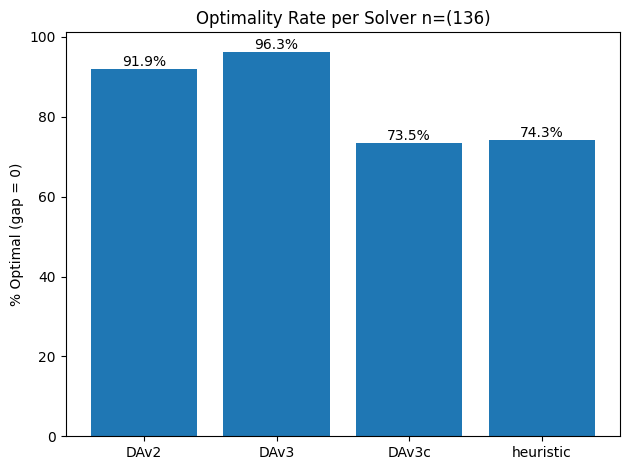

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Optimality Rate per Solver n=(136)'}, ylabel='% Optimal (gap = 0)'>)

In [20]:
count = len(common_df)
labels = opt_df["solver"].tolist()
values = opt_df["%Optimal"].tolist()

plotting.plot_optimality_percentage_per_solver(labels, values, count,'Optimality_Plot.pdf')

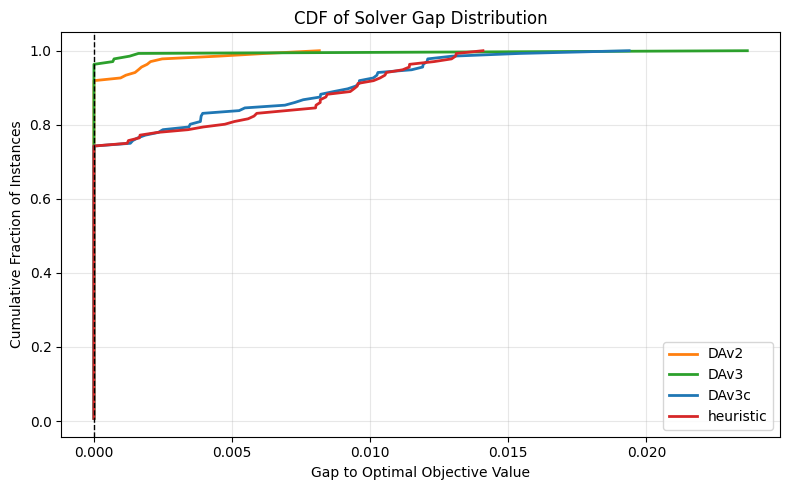

(<Figure size 800x500 with 1 Axes>,
 <Axes: title={'center': 'CDF of Solver Gap Distribution'}, xlabel='Gap to Optimal Objective Value', ylabel='Cumulative Fraction of Instances'>)

In [23]:
plotting.plot_solver_objective_gaps(df=df_final,objective_col="Objective Value",filename='solver_objective_gaps.pdf')

In [25]:
threshold_list = [0.0] + [10**-i for i in range(6, 1, -1)] + [0.05]
analysis_table = utils.get_cdf_table(df=df_final,objective_col="Objective Value",thresholds=threshold_list)

print(analysis_table)

             n Gap ≤ 0.0 Gap ≤ 1e-06 Gap ≤ 1e-05 Gap ≤ 0.0001 Gap ≤ 0.001  \
Solver                                                                      
DAv2       136    91.91%      91.91%      91.91%       91.91%      92.65%   
DAv3       136    96.32%      96.32%      96.32%       96.32%      97.79%   
DAv3c      136    74.26%      74.26%      74.26%       74.26%      74.26%   
heuristic  136    74.26%      74.26%      74.26%       74.26%      74.26%   

          Gap ≤ 0.01 Gap ≤ 0.05  
Solver                           
DAv2         100.00%    100.00%  
DAv3          99.26%    100.00%  
DAv3c         91.91%    100.00%  
heuristic     91.18%    100.00%  
